# Customer Personality Prediction

## Import Modules

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Seaborn Initialization

In [ ]:
sns.set_style("white")
sns.set(rc={"axes.facecolor":"#1E1E1E", "figure.facecolor":"#fffdd0"})
sns.set_style("white", {"axes.grid": False})

## Importing The Dataset

In [ ]:
df=pd.read_csv('marketing_campaign_final.csv')
numeric_cols=df.select_dtypes(include='int64')

## Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

## Data Exploration

Text(0, 0.5, '')

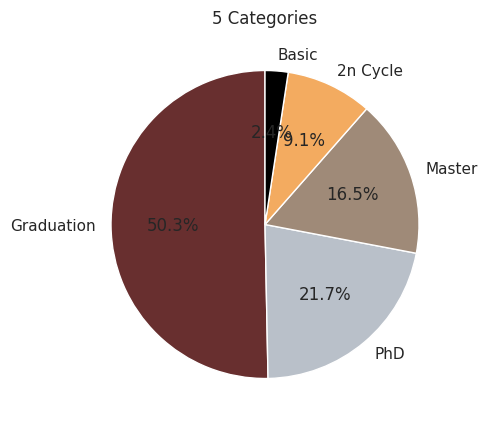

In [ ]:
colors=["#682F2F","#B9C0C9", "#9F8A78","#F3AB60","#000000"]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df['Education'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90,colors=colors)
plt.title('5 Categories')
plt.ylabel('')

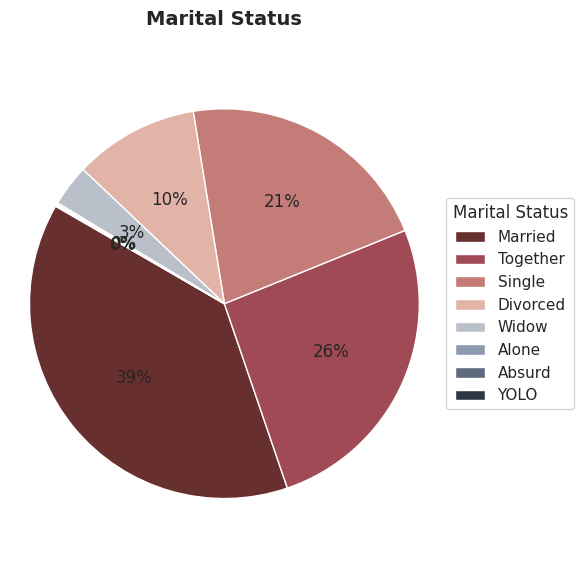

In [ ]:
colors=["#682F2F", "#9F4A54", "#C47C78", "#E2B4A8",
 "#B9C0C9", "#8C9AAE", "#5E6B7F", "#2F3747"]

# ["#682F2F","#B9C0C9", "#9F8A78","#F3AB60","#000000"]
fig, ax = plt.subplots(figsize=(6,6))

values = df['Marital_Status'].value_counts()
ax.pie(values, autopct='%1.0f%%', startangle=150, colors=colors)

ax.legend(values.index, title="Marital Status", loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_title("Marital Status", fontsize=14, fontweight="bold")
ax.axis("equal")
plt.tight_layout()
plt.show()


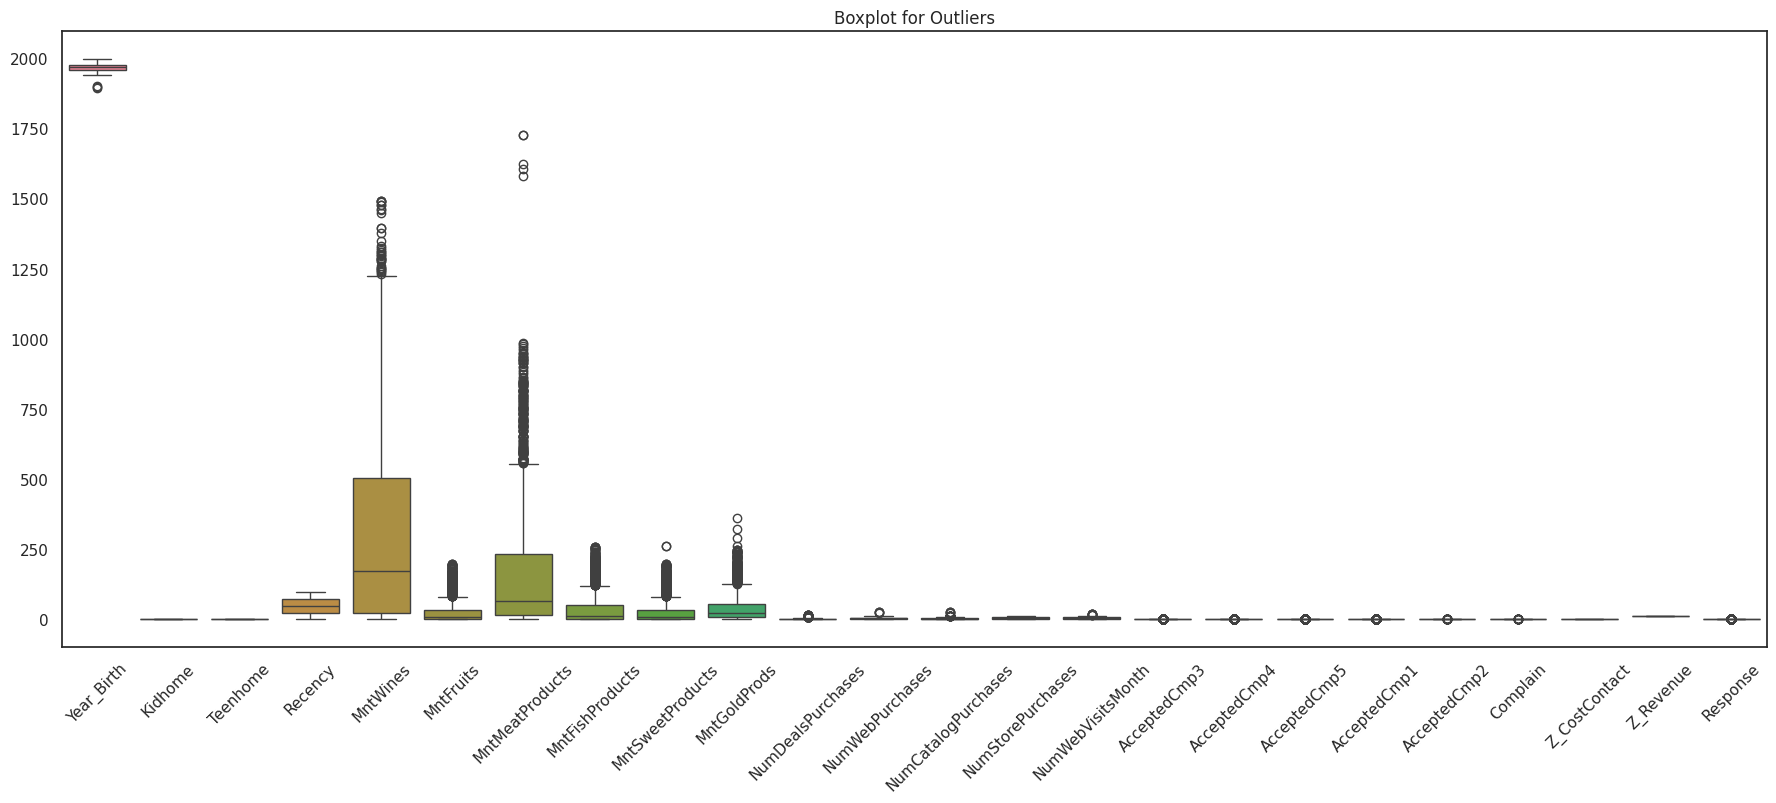

In [ ]:
plt.figure(figsize=(22,8))

cols = [c for c in numeric_cols if c != "Income" and c!="ID"]   # exclude Income
sns.boxplot(data=df[cols])

plt.title("Boxplot for Outliers")
plt.xticks(rotation=45)
plt.show()

## Feature Engineering

In [ ]:
df=df.drop(columns='ID')

In [ ]:
df['Income']=df['Income'].fillna(df['Income'].mean())

In [ ]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], errors="coerce")
today = pd.Timestamp.today()
df["Days_Since_Joining"] = (today - df["Dt_Customer"]).dt.days

In [ ]:
df['Days_Since_Joining']=df['Days_Since_Joining'].fillna(df['Days_Since_Joining'].mean())

In [ ]:
df["Age"] = pd.Timestamp.today().year - df["Year_Birth"]

In [ ]:
df["Children"]=df["Kidhome"]+df["Teenhome"]

In [ ]:
mapping = {
    'Basic': 'Undergraduate',
    '2n Cycle': 'Undergraduate',
    'Graduation': 'Graduate',
    'Master': 'Postgraduate',
    'PhD': 'Postgraduate'
}

df["Education_Level"] = df["Education"].replace(mapping)

In [ ]:
mapping = {
    'Single': 'UnMarried',
    'Together': 'Married',
    'Married': 'Married',
    'Divorced': 'UnMarried',
    'Widow': 'UnMarried',
    'Alone':'UnMarried',
    'Absurd':'UnMarried',
    'YOLO':'Married'
}
df["Marital_Status1"]=df["Marital_Status"].replace(mapping)

In [ ]:
df["Spent"] = df["MntWines"]+ df["MntFruits"]+ df["MntMeatProducts"]+ df["MntFishProducts"]+ df["MntSweetProducts"]+ df["MntGoldProds"]

In [ ]:
to_drop = ["Marital_Status", "Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth"]
df = df.drop(to_drop, axis=1)

In [ ]:
df = df[(df["Income"]<100000)]

In [ ]:
cols_del = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2', 'Complain', 'Response']
df = df.drop(cols_del, axis=1)

## Outlier Clipping

In [ ]:
df_clipped = df.copy()
numeric_cols=df.select_dtypes(include='int64')
for col in numeric_cols:
    Q1 = df_clipped[col].quantile(0.25)
    Q3 = df_clipped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clipped[col] = df_clipped[col].clip(lower, upper)
df=df_clipped

## Data Exploration After FE

Text(0, 0.5, '')

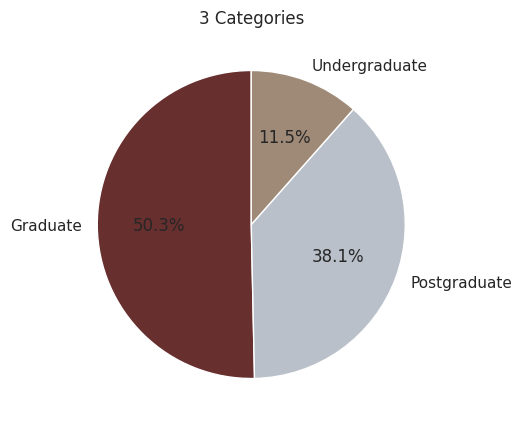

In [ ]:
plt.figure(figsize=(12, 5))
colors=["#682F2F","#B9C0C9", "#9F8A78","#F3AB60","#000000"]
plt.subplot(1, 2, 1)
df['Education_Level'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90,colors=colors)
plt.title('3 Categories')
plt.ylabel('')

Text(0, 0.5, '')

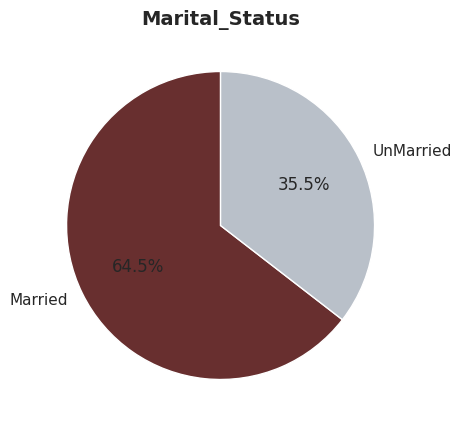

In [ ]:
colors = ["#682F2F","#B9C0C9", "#9F8A78"]
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df['Marital_Status1'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90,colors=colors)
plt.title('Marital_Status',fontsize=14, fontweight='bold')
plt.ylabel('')

/tmp/ipython-input-1024892027.py:25: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.countplot(x=df[col_edu_mapped], ax=axes[2], palette=colors, hue=df[col_edu_mapped], legend=False)


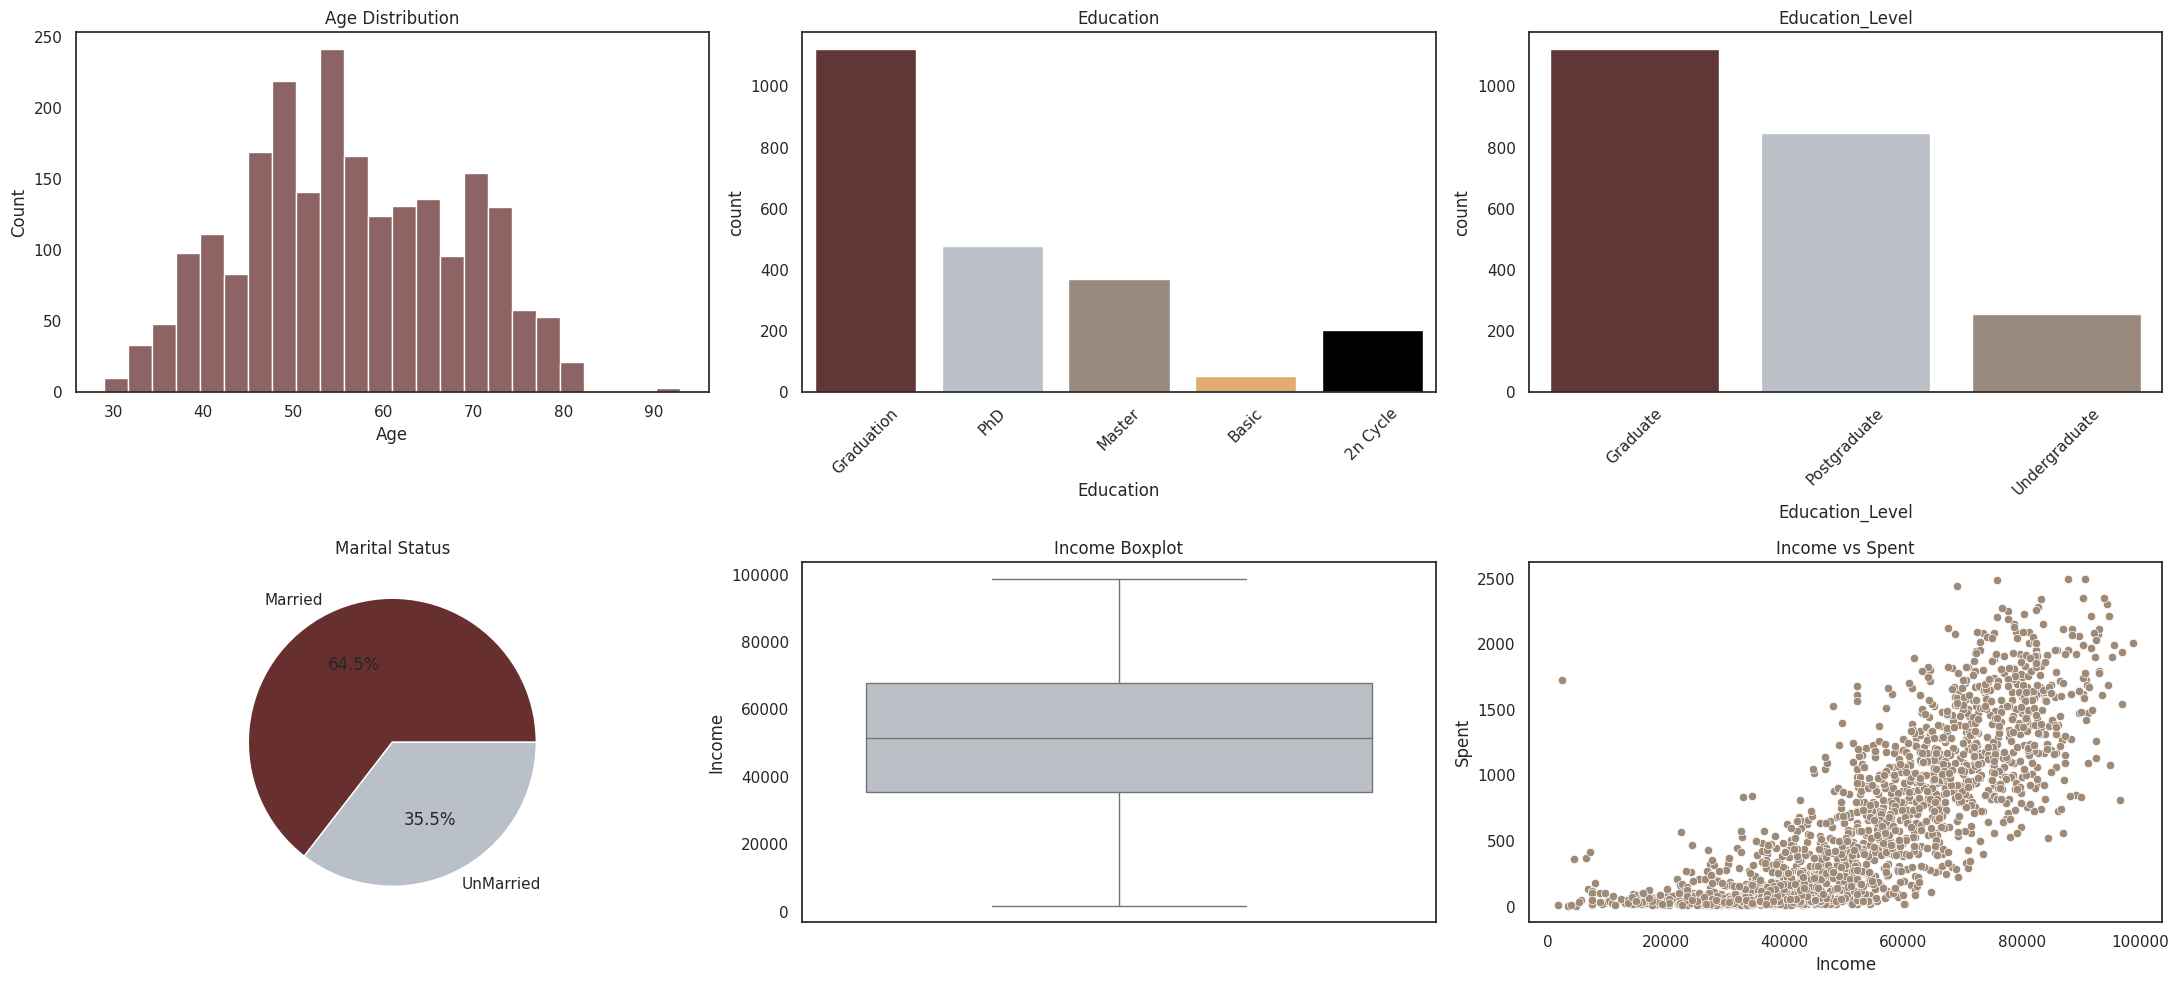

In [ ]:


colors = ["#682F2F", "#B9C0C9", "#9F8A78", "#F3AB60", "#000000"]

col_age = "Age"
col_edu_raw = "Education"
col_edu_mapped = "Education_Level"
col_marital = "Marital_Status1"
col_income = "Income"
col_spent = "Spent"

sns.set_palette(colors)

fig, axes = plt.subplots(2,3, figsize=(22,10))
axes = axes.ravel()

# 1 — Age Histogram
sns.histplot(df[col_age], kde=False, ax=axes[0], color=colors[0])
axes[0].set_title("Age Distribution")

# 2 — Raw Education Countplot
sns.countplot(x=df[col_edu_raw], ax=axes[1], palette=colors, hue=df[col_edu_raw], legend=False)
axes[1].set_title("Education")
axes[1].tick_params(axis='x', rotation=45)

# 3 — Mapped Education Countplot
sns.countplot(x=df[col_edu_mapped], ax=axes[2], palette=colors, hue=df[col_edu_mapped], legend=False)
axes[2].set_title("Education_Level")
axes[2].tick_params(axis='x', rotation=45)

# 4 — Marital Status Pie
df[col_marital].value_counts().plot.pie(
    autopct='%1.1f%%',
    ax=axes[3],
    colors=colors
)
axes[3].set_ylabel("")
axes[3].set_title("Marital Status")

# 5 — Income Boxplot
sns.boxplot(y=df[col_income], ax=axes[4], color=colors[1])
axes[4].set_title("Income Boxplot")

# 6 — Income vs Spent Scatter
sns.scatterplot(x=df[col_income], y=df[col_spent], ax=axes[5], color=colors[2])
axes[5].set_title("Income vs Spent")



plt.tight_layout()
plt.show()

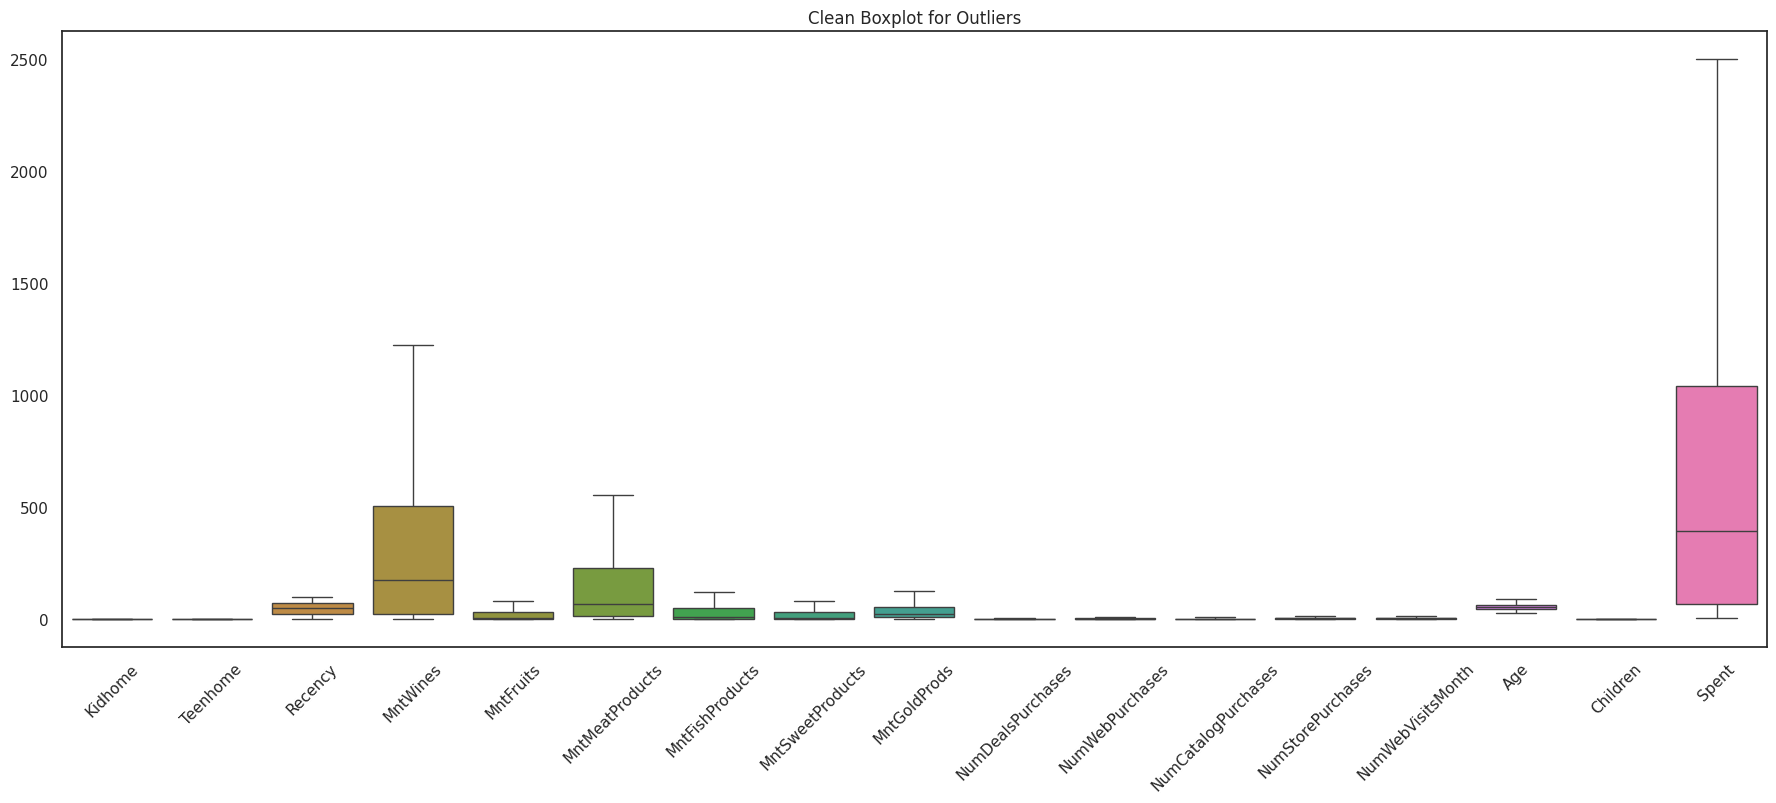

In [ ]:
plt.figure(figsize=(22,8))
cols = [c for c in numeric_cols if c != "Income"]   # exclude Income
sns.boxplot(data=df_clipped[cols])
plt.title("Clean Boxplot for Outliers")
plt.xticks(rotation=45)
plt.show()

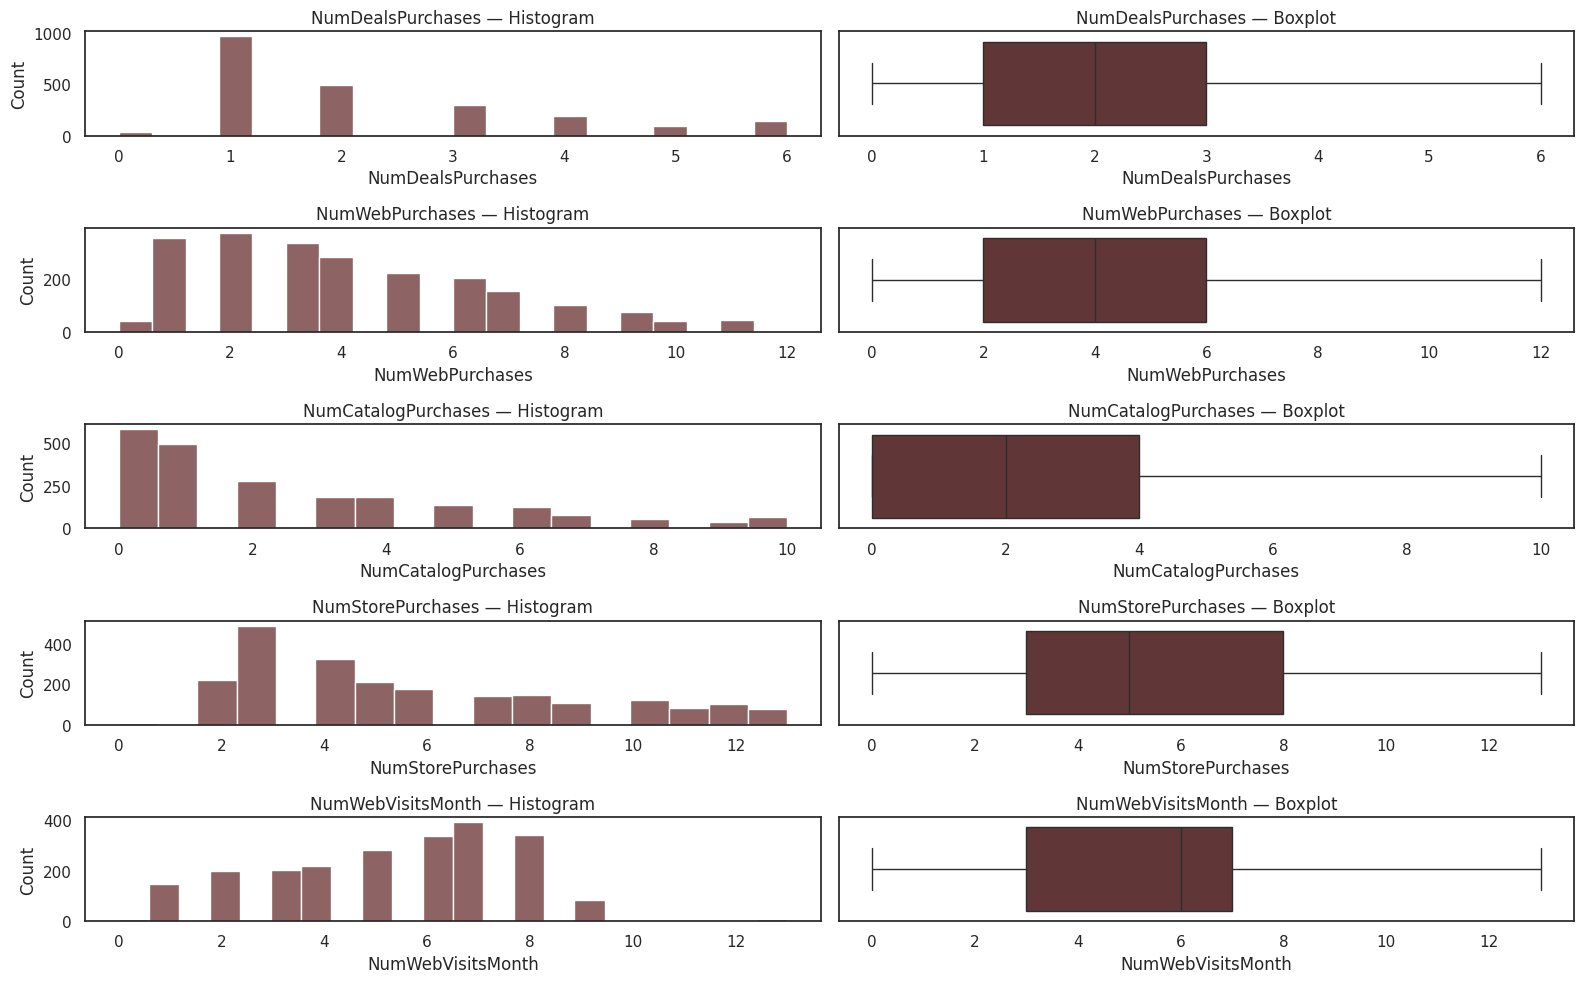

In [ ]:
cols = ["NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases", "NumWebVisitsMonth"]

plt.figure(figsize=(16, 10))

for i, col in enumerate(cols):
    # Histogram
    plt.subplot(len(cols), 2, 2*i + 1)
    sns.histplot(df[col], kde=False)
    plt.title(f"{col} — Histogram")

    # Boxplot
    plt.subplot(len(cols), 2, 2*i + 2)
    sns.boxplot(x=df[col], orient='h')
    plt.title(f"{col} — Boxplot")

plt.tight_layout()
plt.show()


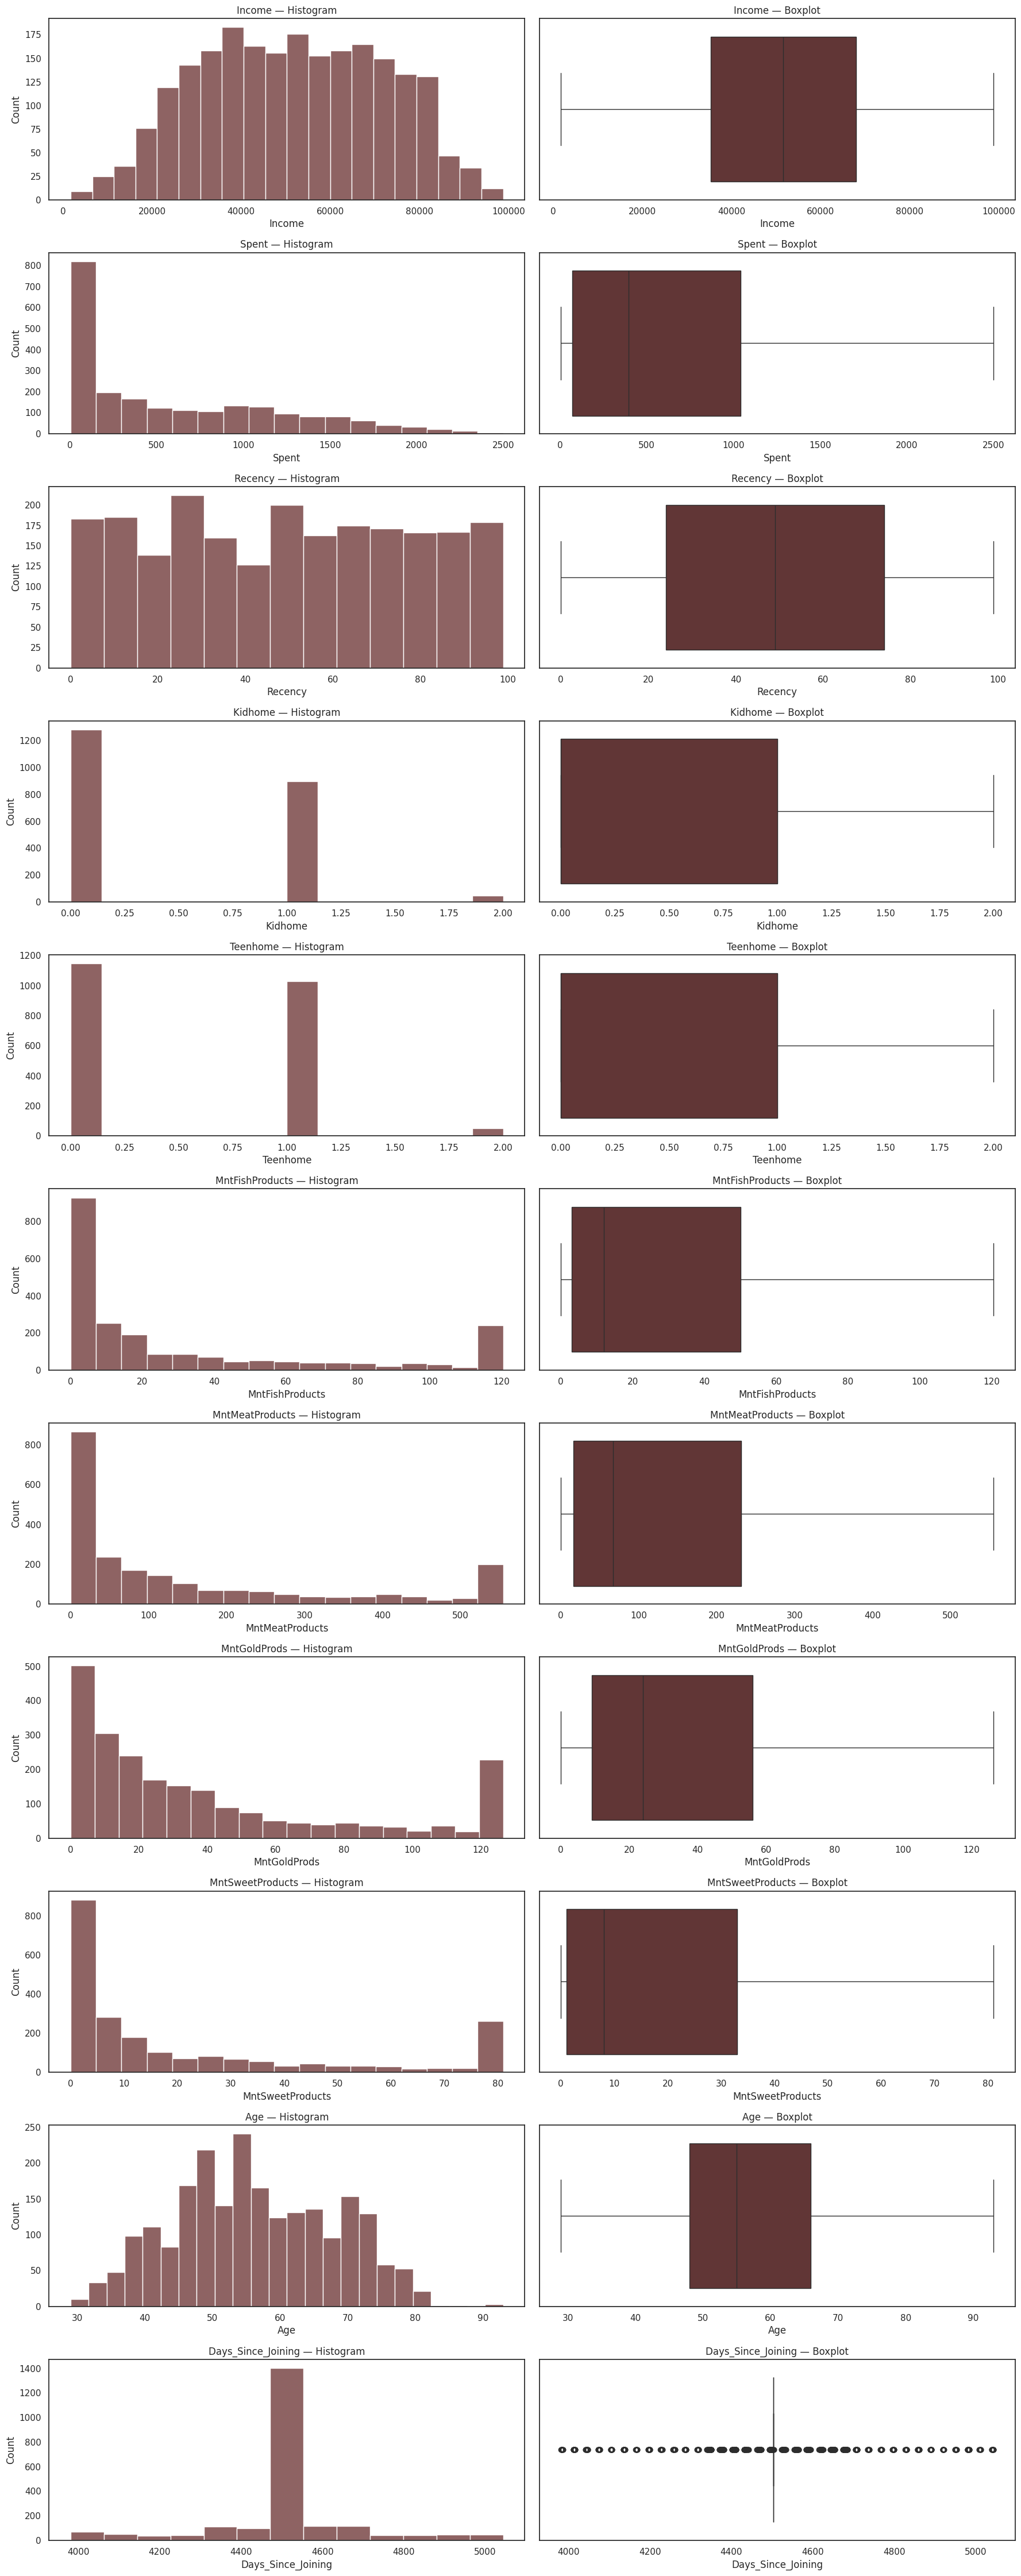

In [ ]:
num_cols_all = [
    "Income","Spent","Recency","Kidhome","Teenhome",
    "MntFishProducts","MntMeatProducts","MntGoldProds",
    "MntSweetProducts","Age","Days_Since_Joining"
]

plt.figure(figsize=(18, 45))

for i, col in enumerate(num_cols_all):
    # Histogram (left)
    plt.subplot(len(num_cols_all), 2, 2*i + 1)
    sns.histplot(df[col], kde=False)
    plt.title(f"{col} — Histogram")

    # Boxplot (right)
    plt.subplot(len(num_cols_all), 2, 2*i + 2)
    sns.boxplot(x=df[col], orient="h")
    plt.title(f"{col} — Boxplot")

plt.tight_layout()
plt.show()


## Encoding Categorical Variables

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
string_cols=df.select_dtypes(include='object').columns.to_list()
ct=ColumnTransformer(transformers=[('encoder',OneHotEncoder(sparse_output=False),string_cols)],remainder='passthrough')
df_transformed = ct.fit_transform(df)


feature_names = ct.get_feature_names_out()
clean_names = [name.replace('encoder__', '').replace('remainder__', '') for name in feature_names]
df = pd.DataFrame(df_transformed, columns=clean_names)

## Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
scaled_df=sc.fit_transform(df)

scaled_df = pd.DataFrame(scaled_df, columns=df.columns)

## Dimensioinality Reduction(PCA)

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3,random_state=0)
pca_df=pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(pca_df,  columns=(["col1","col2", "col3"]))

## Projection of Data Points on 3d

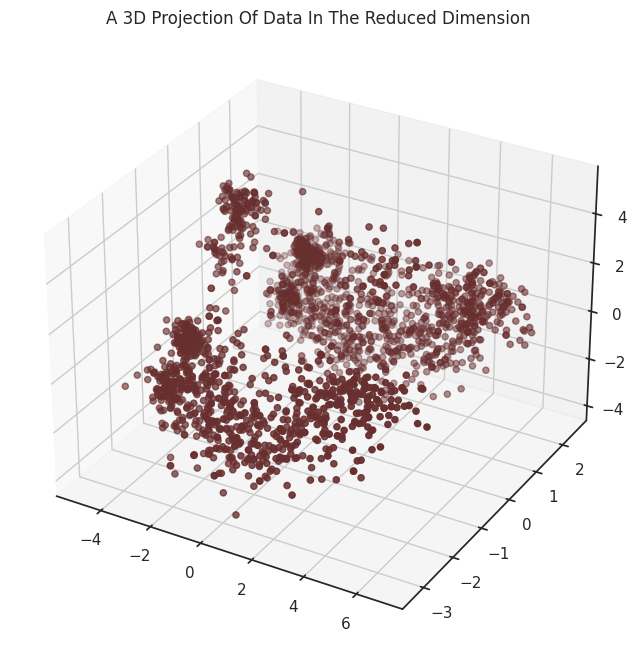

In [ ]:
x =pca_df["col1"]
y =pca_df["col2"]
z =pca_df["col3"]

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x,y,z )
ax.set_title("A 3D Projection Of Data In The Reduced Dimension")
plt.show()

## Kmeans Clustering

### Elbow Method for Optimal Number of Clusters

Elbow Method to determine the number of clusters to be formed:


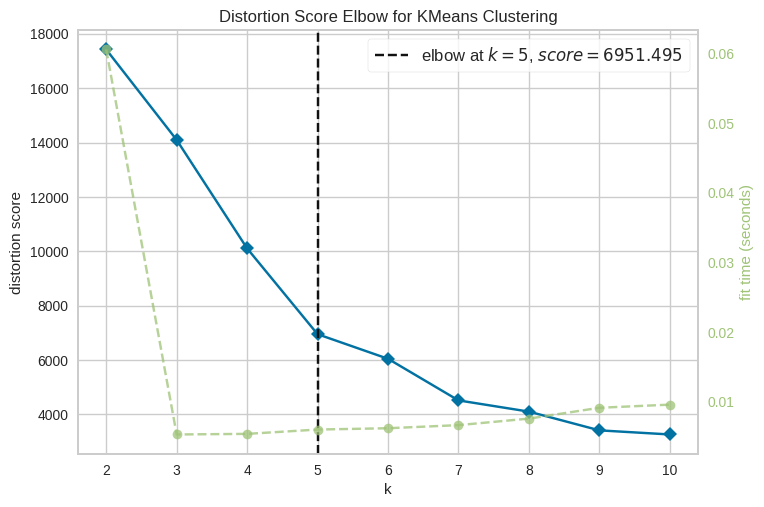

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(KMeans(), k=10)
Elbow_M.fit(pca_df)
Elbow_M.show()

### Clustering

In [ ]:
kmeans=KMeans(n_clusters=5,init='k-means++',random_state=42)
y=kmeans.fit_predict(pca_df)
pca_df["Clusters"]=y
df["Clusters"]=y

### Clusters Visualization

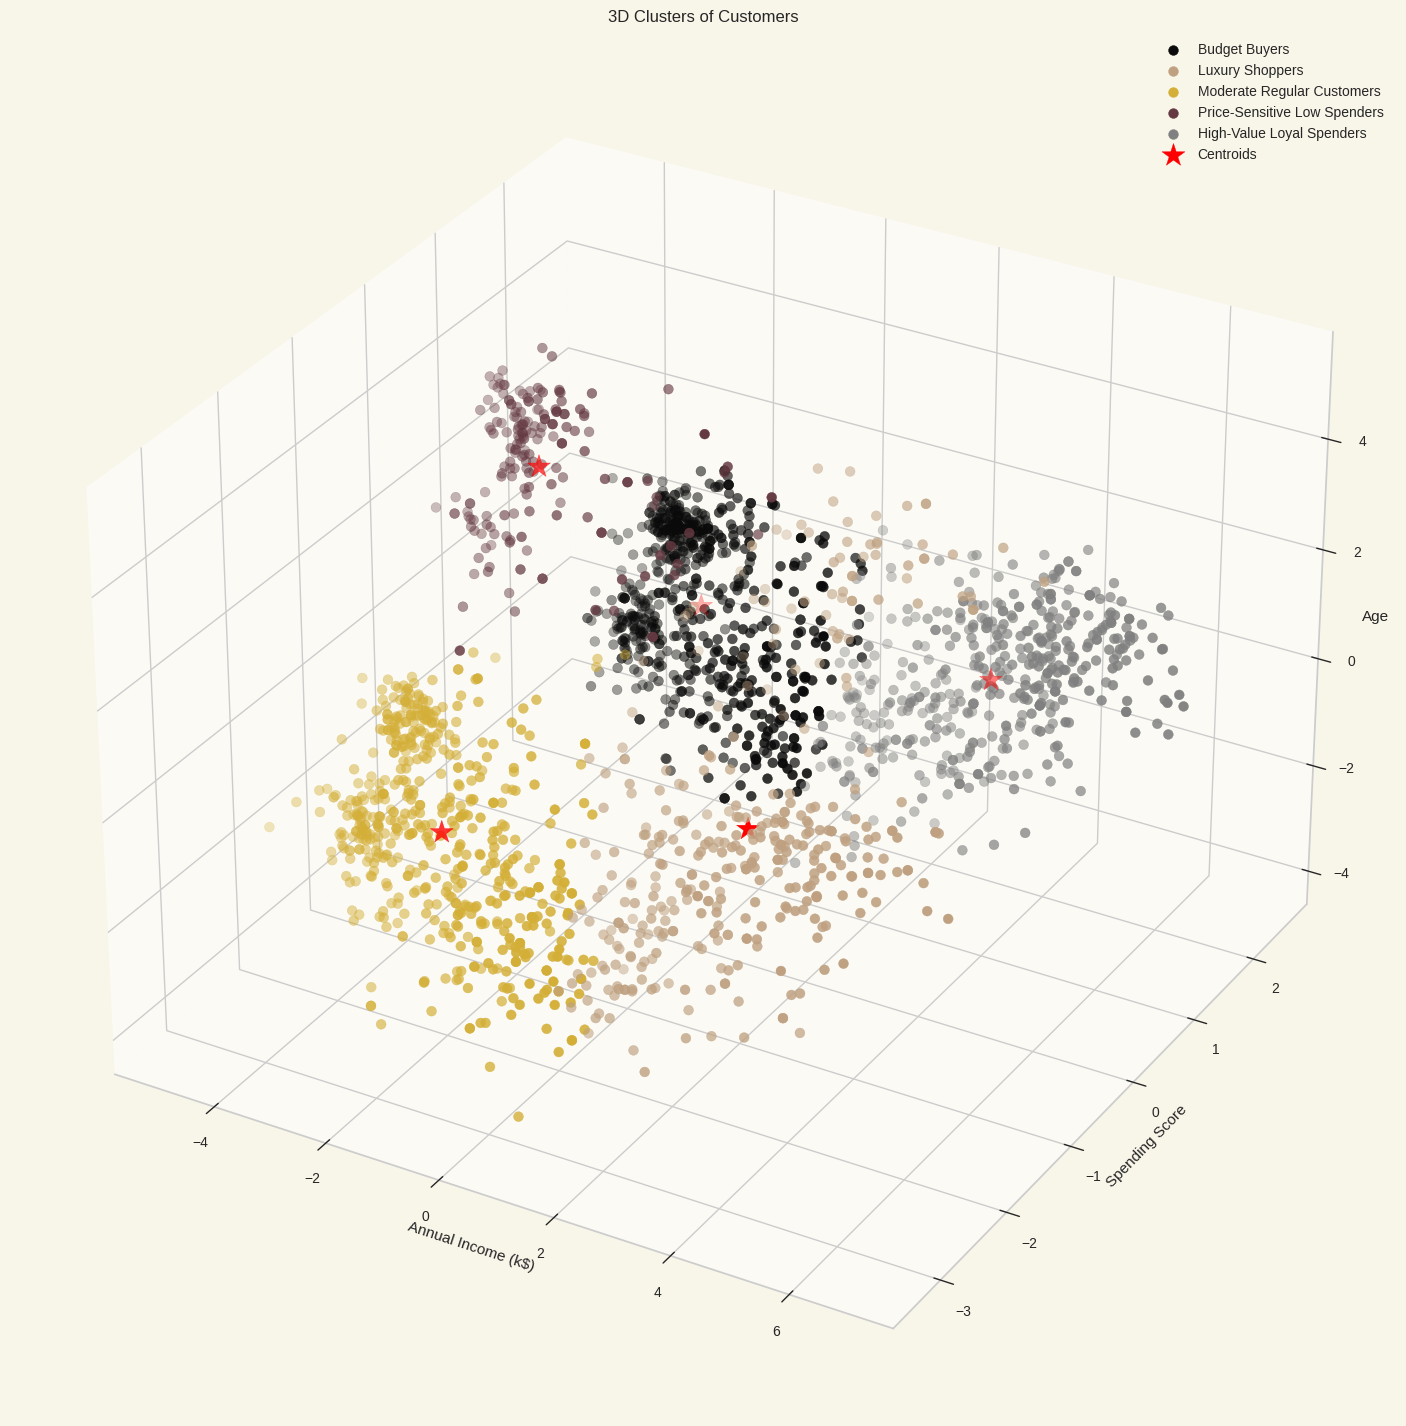

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
X=pca_df
label_map = {
    0: "Budget Buyers",
    1: "Luxury Shoppers",
    2: "Moderate Regular Customers",
    3: "Price-Sensitive Low Spenders",
    4: "High-Value Loyal Spenders"
}

cream = "#f8f5e9"

fig = plt.figure(figsize=(18, 18), facecolor=cream)
ax = fig.add_subplot(111, projection='3d', facecolor=cream)

colors = ["#0A0A0A", "#BFA181", "#D4AF37", "#643941", "grey"]

for c, color in zip(range(5), colors):
    ax.scatter(
        X.loc[y==c, 'col1'], X.loc[y==c, 'col2'], X.loc[y==c, 'col3'],
        s=50, c=color, label=label_map[c]
    )

ax.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    kmeans.cluster_centers_[:,2],
    s=300, c='red', marker='*', label='Centroids'
)

ax.set_title('3D Clusters of Customers', backgroundcolor=cream)
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Age')
ax.legend(facecolor=cream)


ax.xaxis.pane.set_color((1,1,1,0))
ax.yaxis.pane.set_color((1,1,1,0))
ax.zaxis.pane.set_color((1,1,1,0))

plt.show()

### Interactive 3D Visualization

In [ ]:
df.groupby("Clusters")[["Income","Spent","NumWebPurchases","NumStorePurchases","Days_Since_Joining","Age"]].mean()

,Income,Spent,NumWebPurchases,NumStorePurchases,Days_Since_Joining,Age
Clusters,,,,,,
0,38017.760277,191.828267,3.060790,3.937690,4497.727579,54.272036
1,71807.278909,1280.650538,5.653226,8.766129,4526.533526,58.462366
2,44207.030306,280.321881,3.560579,4.576854,4481.020022,58.320072
3,30129.263835,120.850829,2.116022,3.287293,4533.203708,49.580110
4,71505.618796,1223.777538,5.578834,8.503240,4508.299037,57.000000


In [ ]:
import plotly.express as px
import plotly.graph_objs as go


col_x, col_y, col_z = "col1", "col2", "col3"

label_map = {
    0: "Budget Buyers",
    1: "Luxury Shoppers",
    2: "Moderate Regular Customers",
    3: "Price-Sensitive Low Spenders",
    4: "High-Value Loyal Spenders"
}


palette = [
    "#000000",  # desaturated teal
    "#D4A373",  # muted caramel
    "#A68A98",  # soft mauve
    "#B5C0D0",  # pastel blue-grey
    "#E9C46A",  # dull gold
    "#9C6644",  # warm clay
]


n_frames = 90
frame_duration = 90
camera_radius = 1.6


X = X.copy()
X["Segment"] = X["Clusters"].map(label_map)


fig = px.scatter_3d(
    X,
    x=col_x,
    y=col_y,
    z=col_z,
    color="Segment",
    hover_name="Segment",
    opacity=0.85,
    color_discrete_sequence=palette,
)


centers = pd.DataFrame(kmeans.cluster_centers_, columns=['col1','col2','col3'])
centers["Segment"] = "Centroid"


fig.add_scatter3d(
    x=centers['col1'],
    y=centers['col2'],
    z=centers['col3'],
    mode='markers',
    marker=dict(
        size=20,
        color='yellow',
        opacity=0.15,
        symbol="circle"
    ),
    hoverinfo='skip',
    name='Centroid Glow',
    showlegend=False
)


fig.add_scatter3d(
    x=centers['col1'],
    y=centers['col2'],
    z=centers['col3'],
    mode='markers',
    marker=dict(
        size=7,
        color="yellow"
    ),
    hoverinfo='skip',
    name='Centroids'
)



fig.update_traces(marker=dict(line=dict(width=1, color="white")))

fig.update_layout(
    title="3D Customer Segments (Interactive)",
    legend_title="Customer Segments",
    width=900,
    height=720,
    paper_bgcolor="#FFF8E7",
    margin=dict(l=10, r=10, t=70, b=10),
    scene=dict(
        xaxis=dict(showbackground=False, gridcolor="#E6E0D4", zerolinecolor="#E6E0D4", title=col_x),
        yaxis=dict(showbackground=False, gridcolor="#E6E0D4", zerolinecolor="#E6E0D4", title=col_y),
        zaxis=dict(showbackground=False, gridcolor="#E6E0D4", zerolinecolor="#E6E0D4", title=col_z),
        bgcolor="#FFFDF5"
    )
)


start_eye = dict(x=1.25, y=1.25, z=1.1)
fig.update_layout(scene_camera=dict(eye=start_eye))


frames = []
angles = np.linspace(0, 2 * np.pi, n_frames, endpoint=False)

for theta in angles:

    eye = dict(
        x=camera_radius * np.cos(theta),
        y=camera_radius * np.sin(theta),
        z=1.05
    )
    frames.append(go.Frame(layout=dict(scene=dict(camera=dict(eye=eye)))))

fig.frames = frames


fig.update_layout(
    updatemenus=[
        dict(
            type="buttons",
            showactive=False,
            x=0.05,
            y=0.02,
            xanchor="left",
            yanchor="bottom",
            buttons=[
                dict(
                    label="Play",
                    method="animate",
                    args=[
                        None,
                        {
                            "frame": {"duration": frame_duration, "redraw": False},
                            "fromcurrent": True,
                            "transition": {"duration": 0},
                        },
                    ],
                ),
                dict(
                    label="Pause",
                    method="animate",
                    args=[[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate", "transition": {"duration": 0}}],
                ),
            ],
        )
    ]
)
import plotly.graph_objects as go
import numpy as np



frames = []
for angle in np.linspace(0, 360, 120):
    frames.append(go.Frame(layout=dict(
        scene_camera_eye=dict(x=1.5*np.cos(np.radians(angle)),
                              y=1.5*np.sin(np.radians(angle)),
                              z=0.7)
    )))

fig.frames = frames

fig.update_layout(
    updatemenus=[dict(
        type="buttons",
        showactive=False,
        buttons=[
            dict(label="▶ Play", method="animate",
                 args=[None, {"frame": {"duration":80, "redraw":True},
                              "fromcurrent":True, "transition":{"duration":0}}]),
            dict(label="⏸ Pause", method="animate",
                 args=[[None], {"frame":{"duration":0,"redraw":False},
                                "mode":"immediate"}])
        ],
        x=0.1, y=0, direction="left"
    )],
    paper_bgcolor="#f8f5e9",
    plot_bgcolor="#f8f5e9",
)





fig.show()

## After Cluster Visualization

<Figure size 800x550 with 0 Axes>

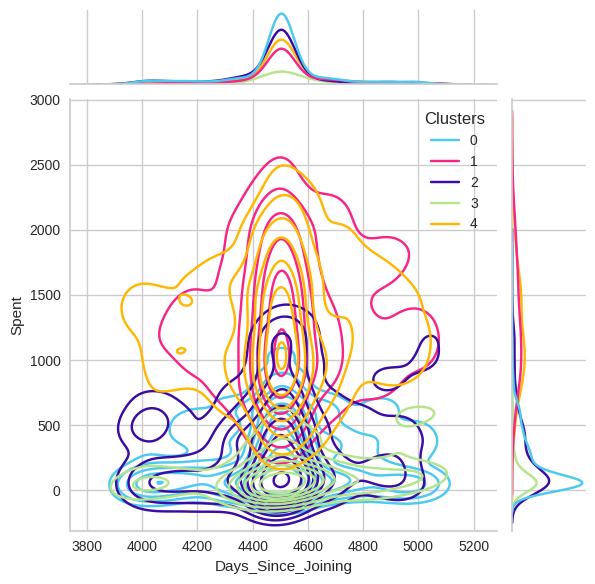

<Figure size 800x550 with 0 Axes>

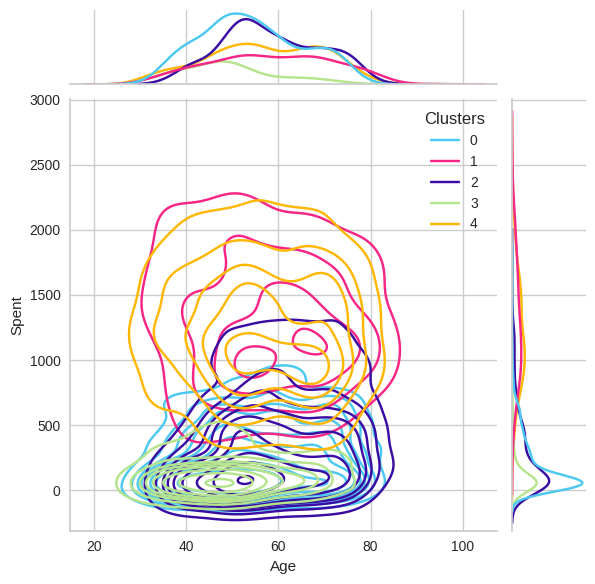

<Figure size 800x550 with 0 Axes>

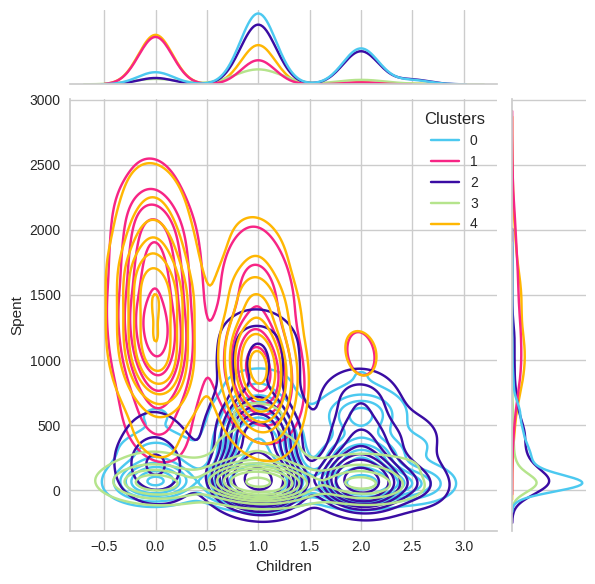

<Figure size 800x550 with 0 Axes>

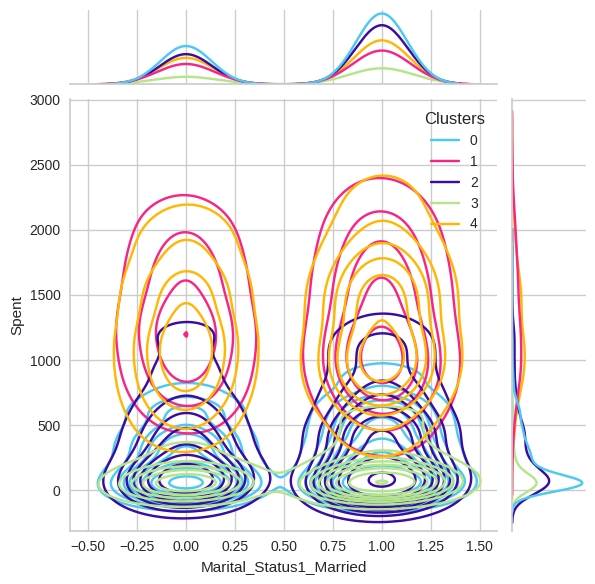

<Figure size 800x550 with 0 Axes>

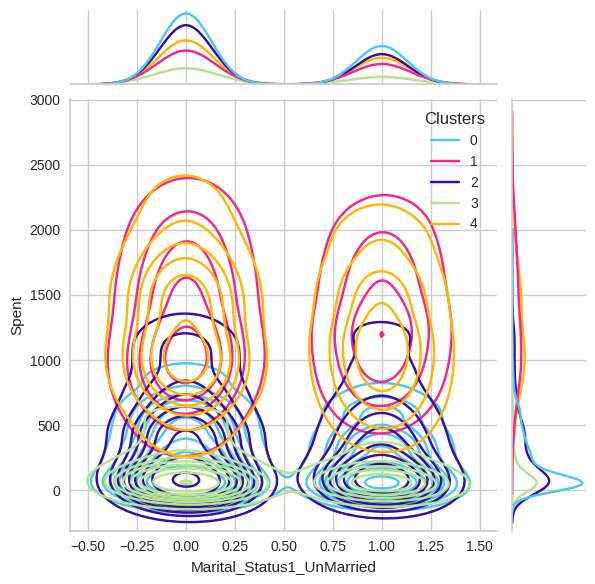

In [ ]:
features = ["Days_Since_Joining", "Age", "Children", "Marital_Status1_Married","Marital_Status1_UnMarried"]
target = "Spent"
pal=["#4CC9F0", "#F72585", "#3A0CA3", "#B5E48C", "#FFB703"]
for i in features:
    plt.figure()
    sns.jointplot(x=df[i], y=df["Spent"], hue =df["Clusters"], kind="kde", palette=pal)
    plt.show()

/tmp/ipython-input-482940245.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




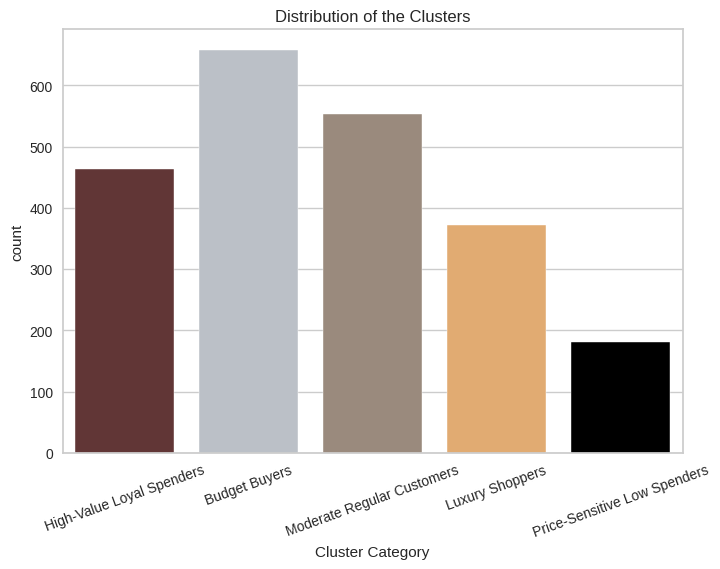

In [ ]:
cluster_map = {
    0: "Budget Buyers",
    1: "Luxury Shoppers",
    2: "Moderate Regular Customers",
    3: "Price-Sensitive Low Spenders",
    4: "High-Value Loyal Spenders"
}

pal = ["#682F2F","#B9C0C9", "#9F8A78","#F3AB60","#000000"]

pl = sns.countplot(
    x=df["Clusters"].replace(cluster_map),
    palette=pal
)
pl.set_title("Distribution of the Clusters")
pl.set_xlabel("Cluster Category")
plt.xticks(rotation=20)
plt.show()


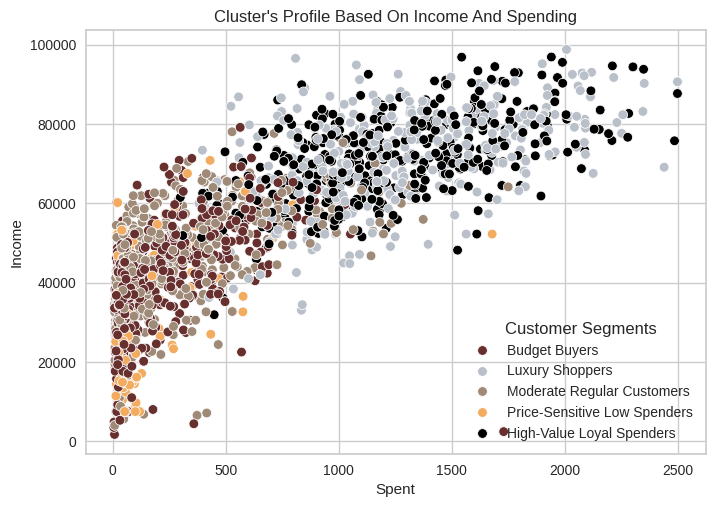

In [ ]:
pl = sns.scatterplot(
    data = df,
    x="Spent",
    y="Income",
    hue="Clusters",
    palette=pal
)


handles, labels = pl.get_legend_handles_labels()
mapped_labels = [cluster_map[int(l)] for l in labels[0:]]

pl.legend(handles[0:], mapped_labels, title="Customer Segments")
pl.set_title("Cluster's Profile Based On Income And Spending")
plt.show()


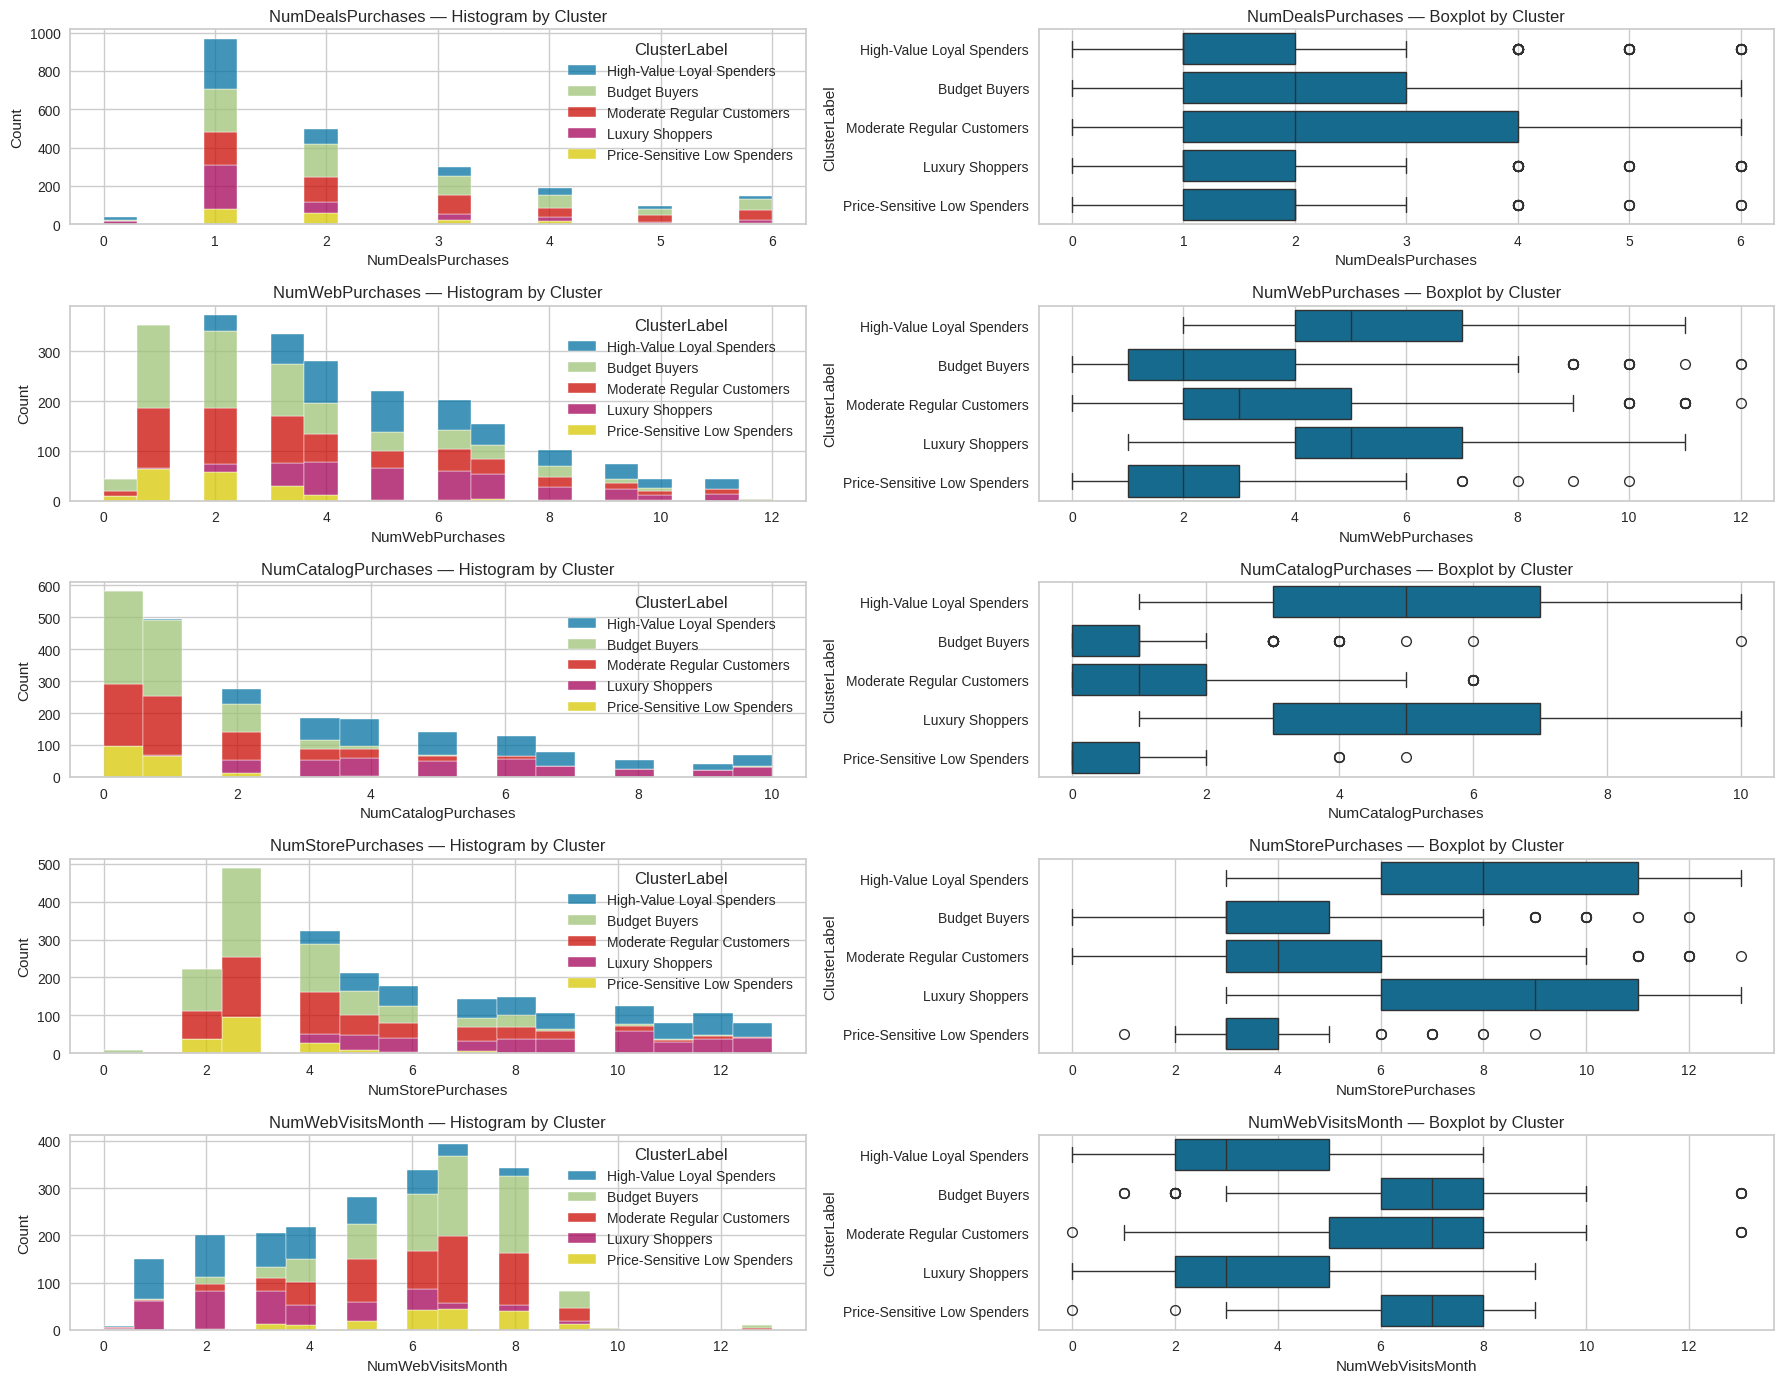

In [ ]:
label_map = {
    0: "Budget Buyers",
    1: "Luxury Shoppers",
    2: "Moderate Regular Customers",
    3: "Price-Sensitive Low Spenders",
    4: "High-Value Loyal Spenders"
}

df["ClusterLabel"] = df["Clusters"].map(label_map)

cols = ["NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases",
        "NumStorePurchases", "NumWebVisitsMonth"]

plt.figure(figsize=(18, 14))

for i, col in enumerate(cols):

    # HISTOGRAM by cluster with text labels
    plt.subplot(len(cols), 2, 2*i + 1)
    sns.histplot(data=df, x=col, hue="ClusterLabel", kde=False, multiple="stack")
    plt.title(f"{col} — Histogram by Cluster")

    # BOX PLOT by cluster with text labels
    plt.subplot(len(cols), 2, 2*i + 2)
    sns.boxplot(data=df, x=col, y="ClusterLabel")
    plt.title(f"{col} — Boxplot by Cluster")

plt.tight_layout()
plt.show()


/tmp/ipython-input-1182245298.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




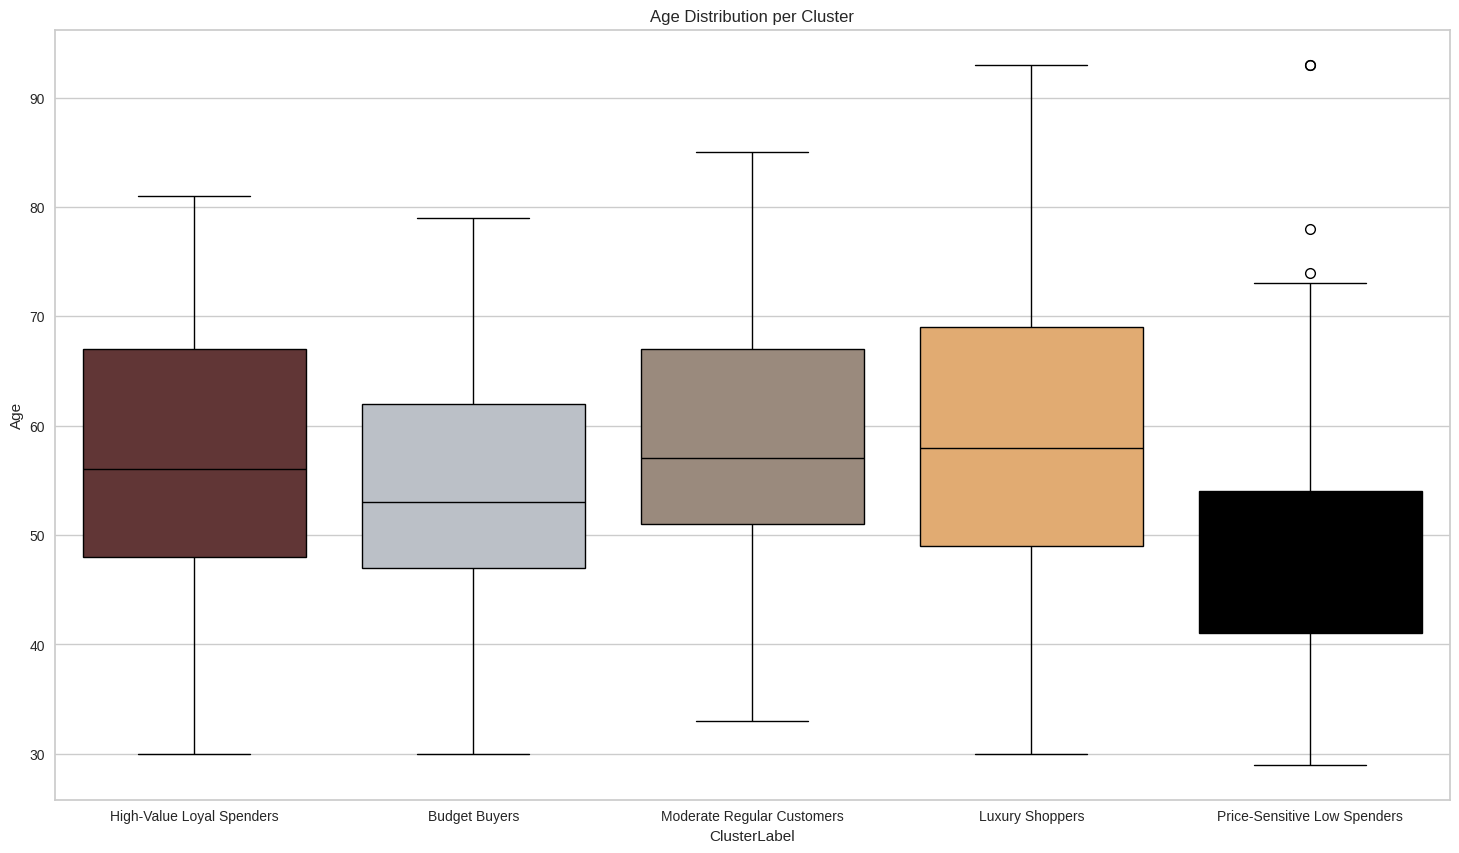

In [ ]:
df["ClusterLabel"] = df["Clusters"].map(cluster_map)

plt.figure(figsize=(18,10))
sns.boxplot(data=df, x="ClusterLabel", y="Age", palette=pal)
plt.title("Age Distribution per Cluster")
plt.show()


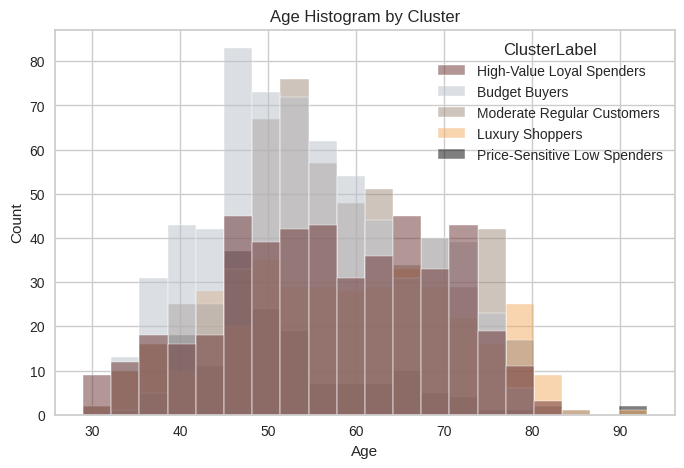

In [ ]:
pal = ["#682F2F","#B9C0C9", "#9F8A78","#F3AB60","#000000"]
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Age", hue="ClusterLabel", palette=pal, kde=False, bins=20)
plt.title("Age Histogram by Cluster")
plt.show()


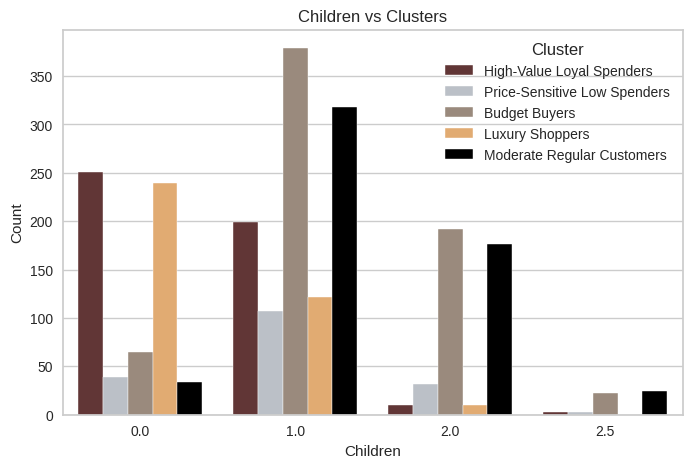

In [ ]:
pal = ["#682F2F","#B9C0C9", "#9F8A78","#F3AB60","#000000"]



plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Children", hue="ClusterLabel", palette=pal)
plt.title("Children vs Clusters")
plt.xlabel("Children")
plt.ylabel("Count")
plt.legend(title="Cluster")
plt.show()

### Profiling

In [ ]:
for c in df["Clusters"].unique():
    subset = df[df["Clusters"] == c]
    name = label_map[c]
    print(f"\n{name} Profile:")
    print(f"- Average Age: {subset['Age'].mean():.1f}")
    print(f"- Average Income: {subset['Income'].mean():.1f}")
    print(f"- Average Spending: {subset['Spent'].mean():.1f}")
    print(f"- Web Purchases: {subset['NumWebPurchases'].mean():.1f}")
    print(f"- Store Purchases: {subset['NumStorePurchases'].mean():.1f}")
    print(f"- Catalog Purchases: {subset['NumCatalogPurchases'].mean():.1f}")
    print(f"- Website Visits: {subset['NumWebVisitsMonth'].mean():.1f}")
    # print(f"- Recency (Days since last purchase): {subset['Recency'].mean():.1f}")



High-Value Loyal Spenders Profile:
- Average Age: 57.0
- Average Income: 71505.6
- Average Spending: 1223.8
- Web Purchases: 5.6
- Store Purchases: 8.5
- Catalog Purchases: 5.2
- Website Visits: 3.6

Budget Buyers Profile:
- Average Age: 54.3
- Average Income: 38017.8
- Average Spending: 191.8
- Web Purchases: 3.1
- Store Purchases: 3.9
- Catalog Purchases: 0.9
- Website Visits: 6.5

Moderate Regular Customers Profile:
- Average Age: 58.3
- Average Income: 44207.0
- Average Spending: 280.3
- Web Purchases: 3.6
- Store Purchases: 4.6
- Catalog Purchases: 1.3
- Website Visits: 6.2

Luxury Shoppers Profile:
- Average Age: 58.5
- Average Income: 71807.3
- Average Spending: 1280.7
- Web Purchases: 5.7
- Store Purchases: 8.8
- Catalog Purchases: 5.4
- Website Visits: 3.5

Price-Sensitive Low Spenders Profile:
- Average Age: 49.6
- Average Income: 30129.3
- Average Spending: 120.9
- Web Purchases: 2.1
- Store Purchases: 3.3
- Catalog Purchases: 0.6
- Website Visits: 6.4
